# Assignment 9.2 - Optimizers



### Check out https://colab.google/ for free GPU resources!

## Task 9.2.1: Optimizer Comparison

* Set up a fully connected neural network model using `PyTorch`. It should be designed for classifying CIFAR10 images. The model should have the following layers: **(RESULT)**
    * Layer1: input_dimension --> 256
    * Layer2: 256 --> 128
    * Layer3: 128 --> 10
    * Use ReLU as your non-linear activation function
* Monitor the learning (loss-function) for different optimizers. Feel free to use `PyTorch`'s implementations for each: **(RESULT)**
    * SGD (with learning rates [0.1, 0.01, 0.001])
    * SGD (with learning rates [0.1, 0.01, 0.001] and 0.9 momentum)
    * Adam
    * AdamW
    * RMSprop

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt


# Simple Fully Connected Model
class SimpleFC(nn.Module):
    def __init__(self):
        super(SimpleFC, self).__init__()
        self.flatten = nn.Flatten()

        # Layer 1: 3072 -> 256
        self.layer1 = nn.Linear(3072, 256)
        # Layer 2: 256 -> 128
        self.layer2 = nn.Linear(256, 128)
        # Layer 3: 128 -> 10
        self.layer3 = nn.Linear(128, 10)

        self.relu = nn.ReLU()
        # Dropout layer with 20% probability
        self.dropout = nn.Dropout(p=0.2)

    def forward(self, x):
        x = self.flatten(x)

        # Apply Dropout after the activation function
        x = self.relu(self.layer1(x))
        x = self.dropout(x)

        x = self.relu(self.layer2(x))
        x = self.dropout(x)

        # Final output layer (No dropout here)
        x = self.layer3(x)
        return x

def get_optimizer(model):
    """Try switching between optim.SGD and optim.Adam!"""
    return optim.Adam(model.parameters(), lr=0.001)

def load_data(batch_size=64):
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])

    train_set = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
    test_set = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False)

    return train_loader, test_loader

def train(model, train_loader, optimizer, criterion, epochs=5):
    model.train()
    for epoch in range(epochs):
        running_loss = 0.0
        for i, (images, labels) in enumerate(train_loader):
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
        print(f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader):.4f}")

def test(model, test_loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    print(f'Accuracy on test images: {100 * correct / total:.2f}%')

# Execution
if __name__ == "__main__":
    train_loader, test_loader = load_data()
    model = SimpleFC()
    optimizer = get_optimizer(model)
    criterion = nn.CrossEntropyLoss()

    train(model, train_loader, optimizer, criterion)
    test(model, test_loader)


100%|██████████| 170M/170M [00:01<00:00, 101MB/s]


Epoch 1, Loss: 1.7269
Epoch 2, Loss: 1.5641
Epoch 3, Loss: 1.4860
Epoch 4, Loss: 1.4331
Epoch 5, Loss: 1.3880
Accuracy on test images: 51.03%


Using device: cpu


Running Experiment: SGD 0.1
  Epoch 1: Loss 1.754 | Accuracy 44.09%
  Epoch 2: Loss 1.559 | Accuracy 44.61%
  Epoch 3: Loss 1.470 | Accuracy 50.25%
  Epoch 4: Loss 1.413 | Accuracy 49.21%
  Epoch 5: Loss 1.362 | Accuracy 50.75%

Running Experiment: SGD 0.01
  Epoch 1: Loss 2.067 | Accuracy 34.68%
  Epoch 2: Loss 1.808 | Accuracy 40.18%
  Epoch 3: Loss 1.708 | Accuracy 42.86%
  Epoch 4: Loss 1.644 | Accuracy 44.75%
  Epoch 5: Loss 1.598 | Accuracy 46.41%

Running Experiment: SGD 0.001
  Epoch 1: Loss 2.285 | Accuracy 22.01%
  Epoch 2: Loss 2.230 | Accuracy 26.07%
  Epoch 3: Loss 2.167 | Accuracy 27.69%
  Epoch 4: Loss 2.109 | Accuracy 28.95%
  Epoch 5: Loss 2.057 | Accuracy 30.63%

Running Experiment: SGD+Mom 0.1
  Epoch 1: Loss 2.156 | Accuracy 20.40%
  Epoch 2: Loss 2.192 | Accuracy 19.32%
  Epoch 3: Loss 2.154 | Accuracy 20.57%
  Epoch 4: Loss 2.145 | Accuracy 19.08%
  Epoch 5: Loss 2.149 | Accuracy 20.76%

Running Experiment: SGD+Mom 0.01
  Epoch 1: Loss 1.766 | 

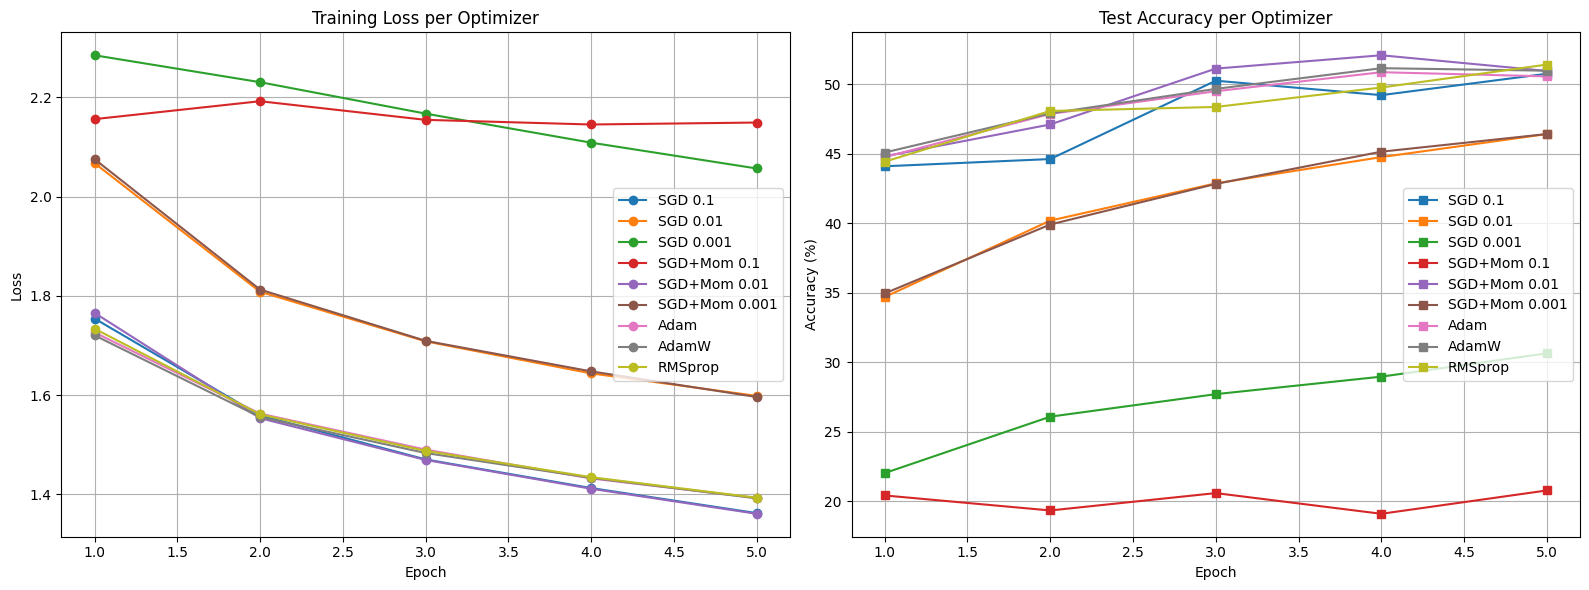

In [ ]:
# Setup - use CPU for simplicity
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}\n")

def train_and_track_with_val(optimizer_func, train_loader, test_loader, epochs=5):
    model = SimpleFC().to(device)
    optimizer = optimizer_func(model)
    criterion = nn.CrossEntropyLoss()

    stats = {'loss': [], 'accuracy': []}

    for epoch in range(epochs):
        # --- Training Phase ---
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        avg_loss = running_loss / len(train_loader)
        stats['loss'].append(avg_loss)

        # --- Validation Phase ---
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        acc = 100 * correct / total
        stats['accuracy'].append(acc)
        print(f"  Epoch {epoch+1}: Loss {avg_loss:.3f} | Accuracy {acc:.2f}%")

    return stats

# Running the expanded experiments
train_loader, test_loader = load_data() # Ensure test_loader is loaded
all_results = {}

# 1. Define the Experiments Dictionary
experiments = {
    "SGD 0.1": lambda m: optim.SGD(m.parameters(), lr=0.1),
    "SGD 0.01": lambda m: optim.SGD(m.parameters(), lr=0.01),
    "SGD 0.001": lambda m: optim.SGD(m.parameters(), lr=0.001),
    "SGD+Mom 0.1": lambda m: optim.SGD(m.parameters(), lr=0.1, momentum=0.9),
    "SGD+Mom 0.01": lambda m: optim.SGD(m.parameters(), lr=0.01, momentum=0.9),
    "SGD+Mom 0.001": lambda m: optim.SGD(m.parameters(), lr=0.001, momentum=0.9),
    "Adam": lambda m: optim.Adam(m.parameters(), lr=0.001),
    "AdamW": lambda m: optim.AdamW(m.parameters(), lr=0.001),
    "RMSprop": lambda m: optim.RMSprop(m.parameters(), lr=0.001)
}

# 2. Run the experiments
all_results = {}

for name, opt_func in experiments.items():
    print(f"\nRunning Experiment: {name}")
    all_results[name] = train_and_track_with_val(opt_func, train_loader, test_loader, epochs=5)

# 3. Plotting results (Fixed indentation)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for name, stats in all_results.items():
    ax1.plot(range(1, 6), stats['loss'], label=name, marker='o')
    ax2.plot(range(1, 6), stats['accuracy'], label=name, marker='s')

ax1.set_title('Training Loss per Optimizer')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

ax2.set_title('Test Accuracy per Optimizer')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()